# Analysis

Train the various algorithms and show your results. 

You must plot the reward obtained by your agent per step and the total regret accumulated so far.

This one is an open ended assignment, so feel free to play around. Extra credit for more beautiful plots (you can check out Seaborn). 

In [58]:
import warnings ; warnings.filterwarnings('ignore')
from pprint import pprint
from itertools import cycle

In [59]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab 
# import seaborn as sns
# import sys
# import os
# module_path = os.path.abspath(os.path.join('.'))
# if module_path not in sys.path:
#     sys.path.append(module_path)

from bandits import Bandit
from agents import *

np.random.seed(123)

%matplotlib inline

In [60]:
plt.style.use('fivethirtyeight')
params = {
    'figure.figsize': (15, 8),
    'font.size': 24,
    'legend.fontsize': 20,
    'axes.titlesize': 28,
    'axes.labelsize': 24,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20
}
pylab.rcParams.update(params)
np.set_printoptions(suppress=True)

In [61]:
# Create Bandits: (5-armed bandits)
banditBern = Bandit(n=5, type='Bernoulli')
banditGauss = Bandit(n=5, type='Gaussian')

In [62]:
# checking the bandits functions
print(banditBern.getN())
print(banditGauss.getN())

5
5


In [63]:
print(banditGauss.means)
print(banditGauss.optimal)

[18.22106068 14.48482279 12.95799035 34.79348433 -1.19300065]
34.793484327778486


In [64]:
# create agents
agentsBern = [GreedyAgent(banditBern), epsGreedyAgent(banditBern), UCBAAgent(banditBern), GradientBanditAgent(banditBern), ThompsonSamplerAgent(banditBern)]

agentsGauss = [GreedyAgent(banditGauss), epsGreedyAgent(banditGauss), UCBAAgent(banditGauss), GradientBanditAgent(banditGauss), ThompsonSamplerAgent(banditGauss)]


In [65]:
nameOfAgent=['Greedy', 'Epsilon Greedy', 'UCBA', 'Gradient Bandit', 'Thompson Sampler']

In [35]:
# agentsBern[0] for demo
i=4
agent=agentsBern[i]
n_episodes = 1000
Qe=np.empty((n_episodes, banditBern.getN()), dtype=np.float64)
returns = np.empty(n_episodes, dtype=np.float64)
actions = np.empty(n_episodes, dtype=int)

for e in range(n_episodes):
    action=agent.action() if i != 2 else agent.action(e)
    reward=banditBern.choose(action)
    agent.update(action, reward)
    Q, N = agent.getQN()
    Qe[e]=Q
    returns[e] = reward
    actions[e]=action


In [41]:
name=nameOfAgent[i]
print(name)
print(f'Probability of Rewards in: {banditBern.probs}')
print(f'Optimal Rewards: {banditBern.optimal}')
print('_'*50)

Thompson Sampler
Probability of Rewards in: [0.69646919 0.28613933]
Optimal Rewards: 0.6964691855978616
__________________________________________________


In [37]:
results={}
true_Q=banditBern.probs
opt_V=banditBern.optimal
name,Re,Qe,Ae=name,returns,Qe,actions
Ae=np.expand_dims(Ae,-1)
episode_mean_rew = np.cumsum(Re) / (np.arange(len(Re)) + 1)
Q_selected = np.take_along_axis(
                    np.tile(true_Q, Ae.shape), Ae, axis=1).squeeze()
regret = opt_V - Q_selected
cum_regret = np.cumsum(regret)
if name not in results.keys(): results[name] = {}
if 'Re' not in results[name].keys(): results[name]['Re'] = []
if 'Qe' not in results[name].keys(): results[name]['Qe'] = []
if 'Ae' not in results[name].keys(): results[name]['Ae'] = []
if 'cum_regret' not in results[name].keys(): 
                    results[name]['cum_regret'] = []
if 'episode_mean_rew' not in results[name].keys(): 
                results[name]['episode_mean_rew'] = []

results[name]['Re'].append(Re)
results[name]['Qe'].append(Qe)
results[name]['Ae'].append(Ae)
results[name]['cum_regret'].append(cum_regret)
results[name]['episode_mean_rew'].append(episode_mean_rew)

In [38]:
print(results)

{'Thompson Sampler': {'Re': [array([1., 0., 1., 0., 0., 0., 1., 0., 1., 0., 0., 1., 0., 0., 1., 0., 1.,
       1., 1., 1., 0., 0., 1., 1., 1., 0., 1., 0., 1., 1., 1., 1., 0., 1.,
       1., 1., 0., 1., 0., 1., 0., 1., 1., 1., 0., 0., 1., 1., 1., 0., 1.,
       0., 0., 1., 1., 0., 0., 0., 1., 0., 1., 0., 1., 1., 1., 0., 0., 0.,
       0., 1., 1., 0., 1., 1., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1.,
       0., 1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 0., 0., 1., 1., 0.,
       1., 1., 0., 1., 1., 1., 1., 1., 0., 0., 1., 0., 0., 1., 1., 1., 0.,
       1., 0., 0., 1., 1., 1., 1., 1., 1., 0., 1., 0., 1., 1., 1., 1., 1.,
       0., 1., 1., 1., 1., 0., 0., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1.,
       0., 1., 0., 1., 0., 1., 1., 0., 1., 1., 0., 1., 0., 0., 1., 1., 1.,
       1., 1., 1., 1., 1., 0., 0., 1., 1., 0., 1., 1., 1., 1., 1., 0., 1.,
       1., 1., 1., 0., 1., 1., 1., 1., 0., 0., 1., 1., 1., 1., 1., 0., 0.,
       1., 1., 0., 1., 1., 1., 1., 1., 1., 0., 1., 0., 0., 0., 1., 1., 

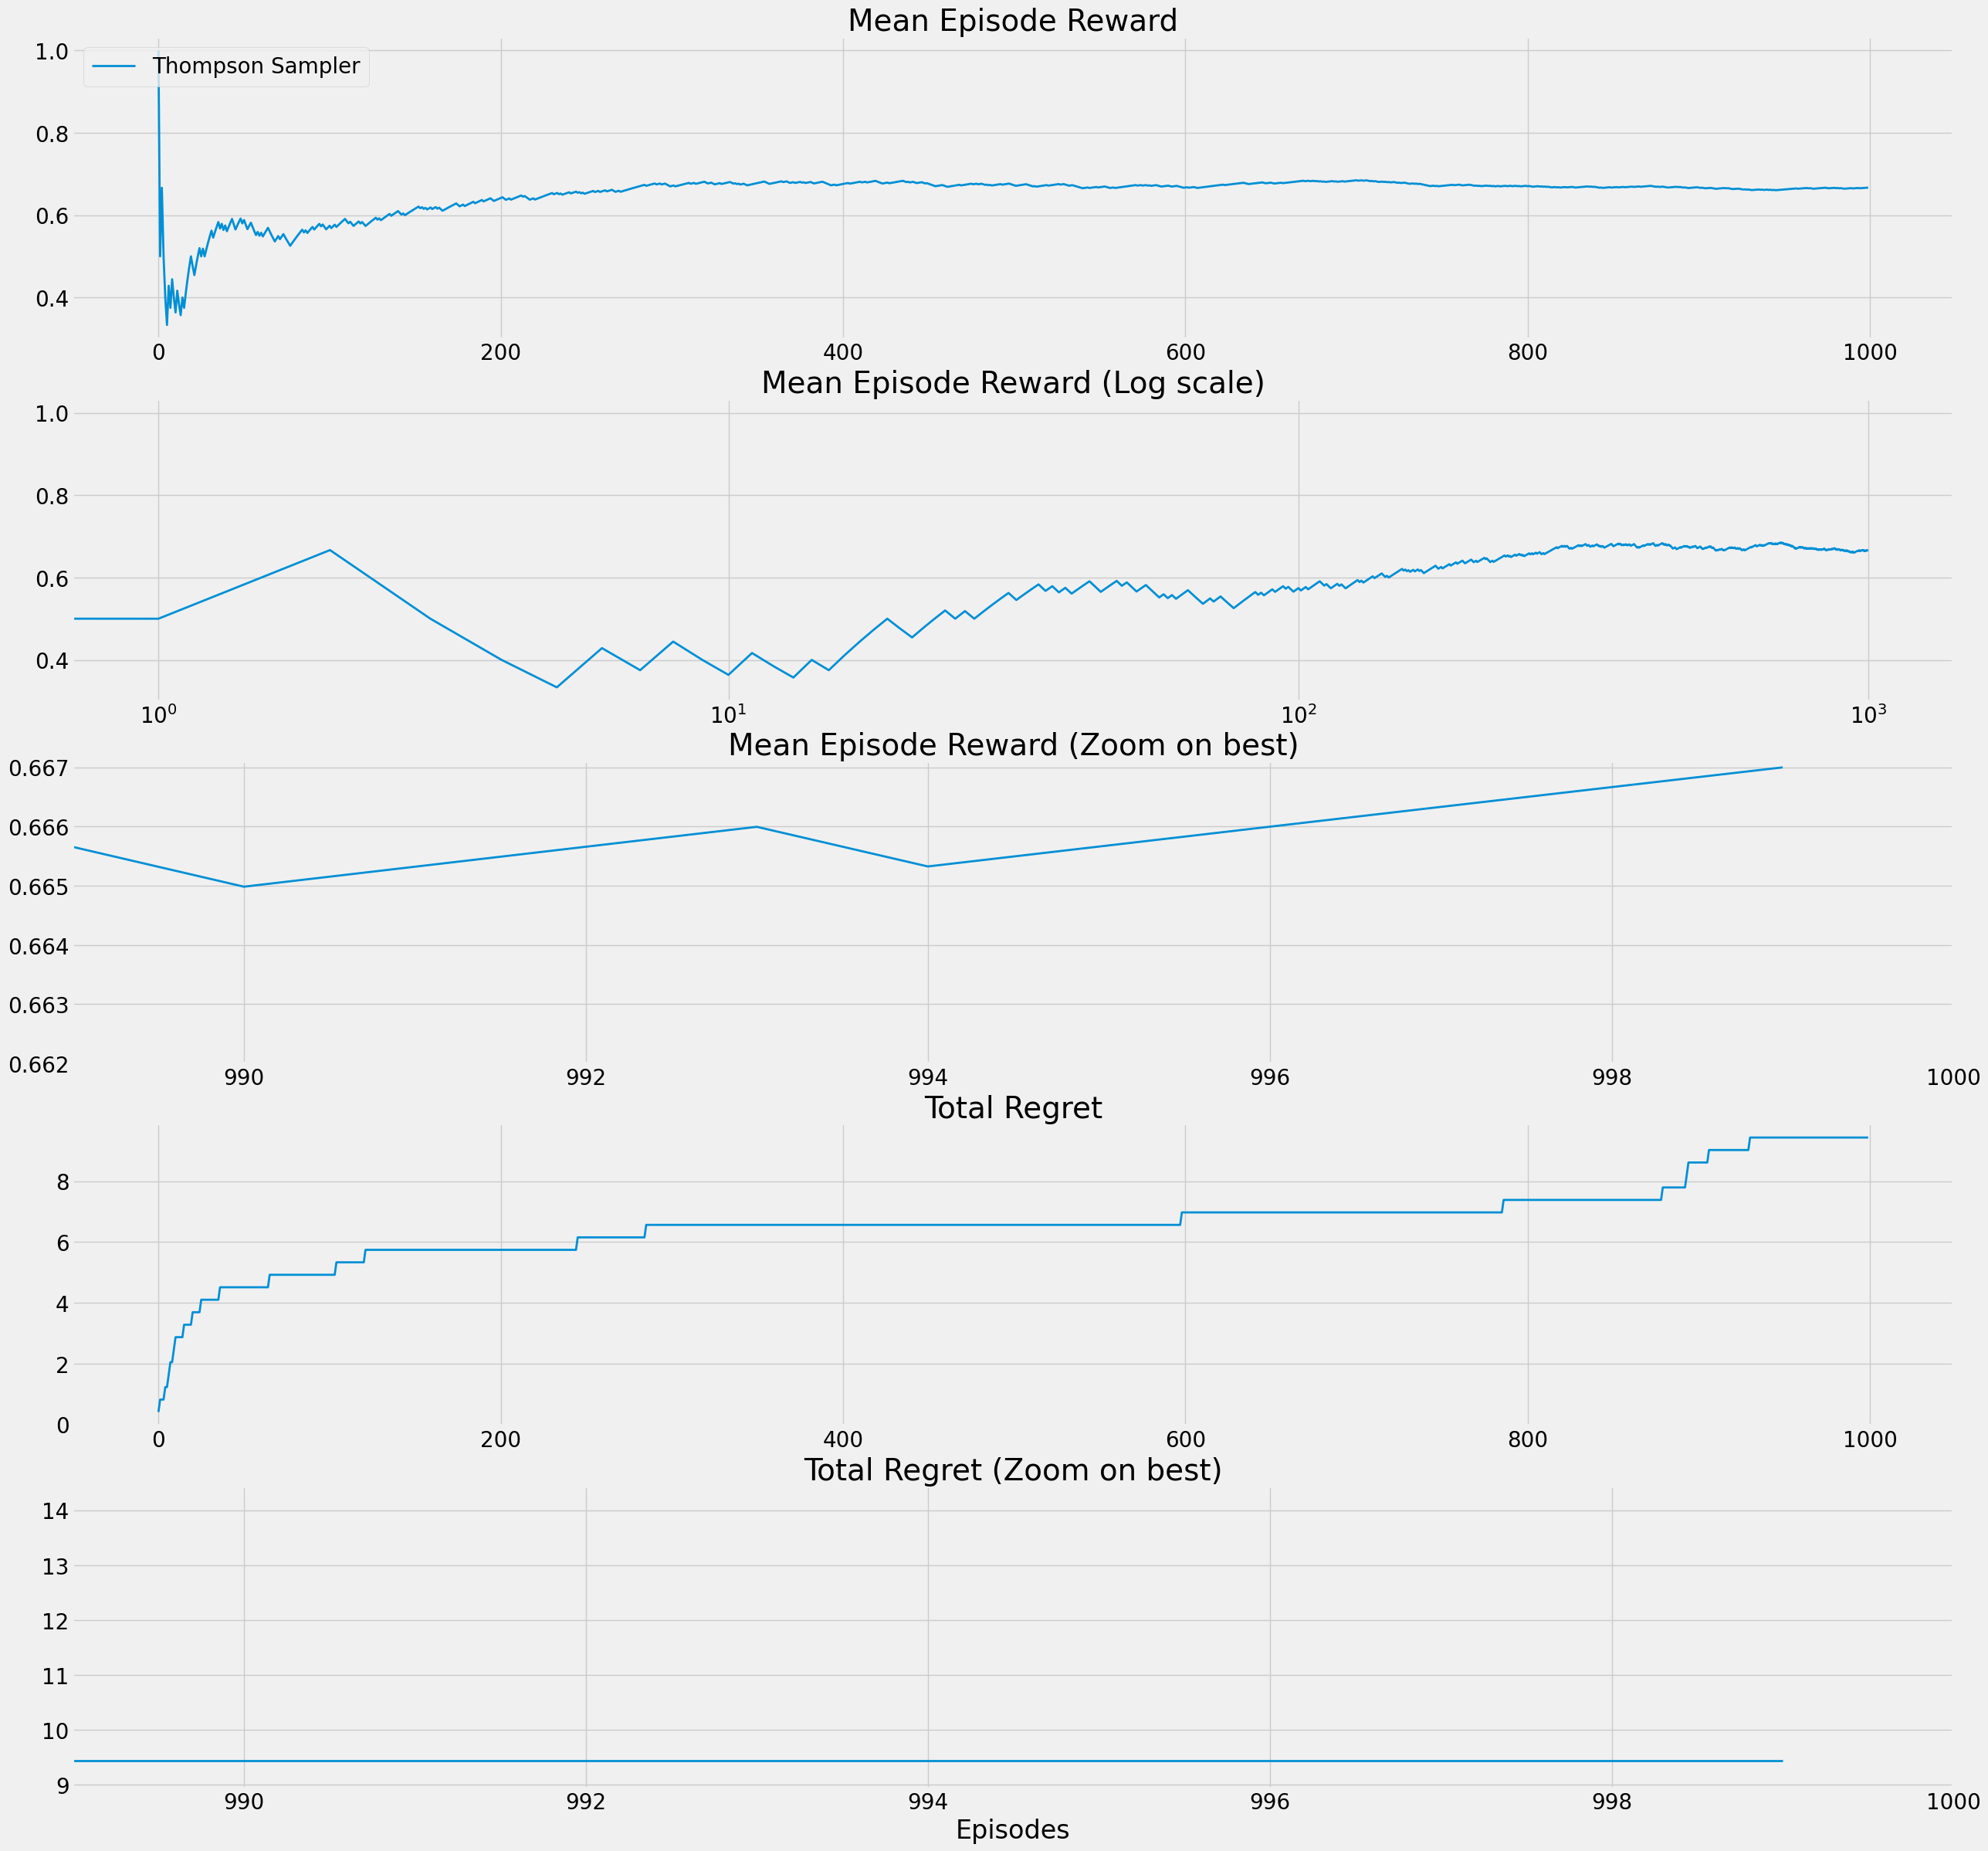

In [39]:
fig, axs = plt.subplots(5, 1, figsize=(28, 28), sharey=False, sharex=False)

lines = ["-","--",":","-."]
linecycler = cycle(lines)
min_reg, max_ret = float('inf'), float('-inf')
for label, result in results.items():
    color = next(linecycler)

    # reward
    episode_mean_rew = np.array(result['episode_mean_rew'])
    mean_episode_mean_rew = np.mean(episode_mean_rew, axis=0)

    axs[0].plot(mean_episode_mean_rew, color, linewidth=2, label=label)

    axs[1].plot(mean_episode_mean_rew, color, linewidth=2, label=label)
    axs[1].set_xscale('log')
    
    axs[2].plot(mean_episode_mean_rew, color, linewidth=2, label=label)
    if max_ret < mean_episode_mean_rew[-1]: max_ret = mean_episode_mean_rew[-1]
    axs[2].axis((mean_episode_mean_rew.shape[0]*0.989,
                 mean_episode_mean_rew.shape[0],
                 max_ret-0.005,
                 max_ret+0.0001))

    # regret
    cum_regret = np.array(result['cum_regret'])
    mean_cum_regret = np.mean(cum_regret, axis=0)

    axs[3].plot(mean_cum_regret, color, linewidth=2, label=label)
    
    axs[4].plot(mean_cum_regret, color, linewidth=2, label=label)
    if min_reg > mean_cum_regret[-1]: min_reg = mean_cum_regret[-1]
    plt.axis((mean_cum_regret.shape[0]*0.989,
              mean_cum_regret.shape[0],
              min_reg-0.5,
              min_reg+5))

    # config plot
    axs[0].set_title('Mean Episode Reward')
    axs[1].set_title('Mean Episode Reward (Log scale)')
    axs[2].set_title('Mean Episode Reward (Zoom on best)')
    axs[3].set_title('Total Regret')
    axs[4].set_title('Total Regret (Zoom on best)')
    plt.xlabel('Episodes')
    axs[0].legend(loc='upper left')

plt.show()

Probability of Rewards in: [0.69646919 0.28613933 0.22685145 0.55131477 0.71946897]
Optimal Rewards: 0.7194689697855631
__________________________________________________


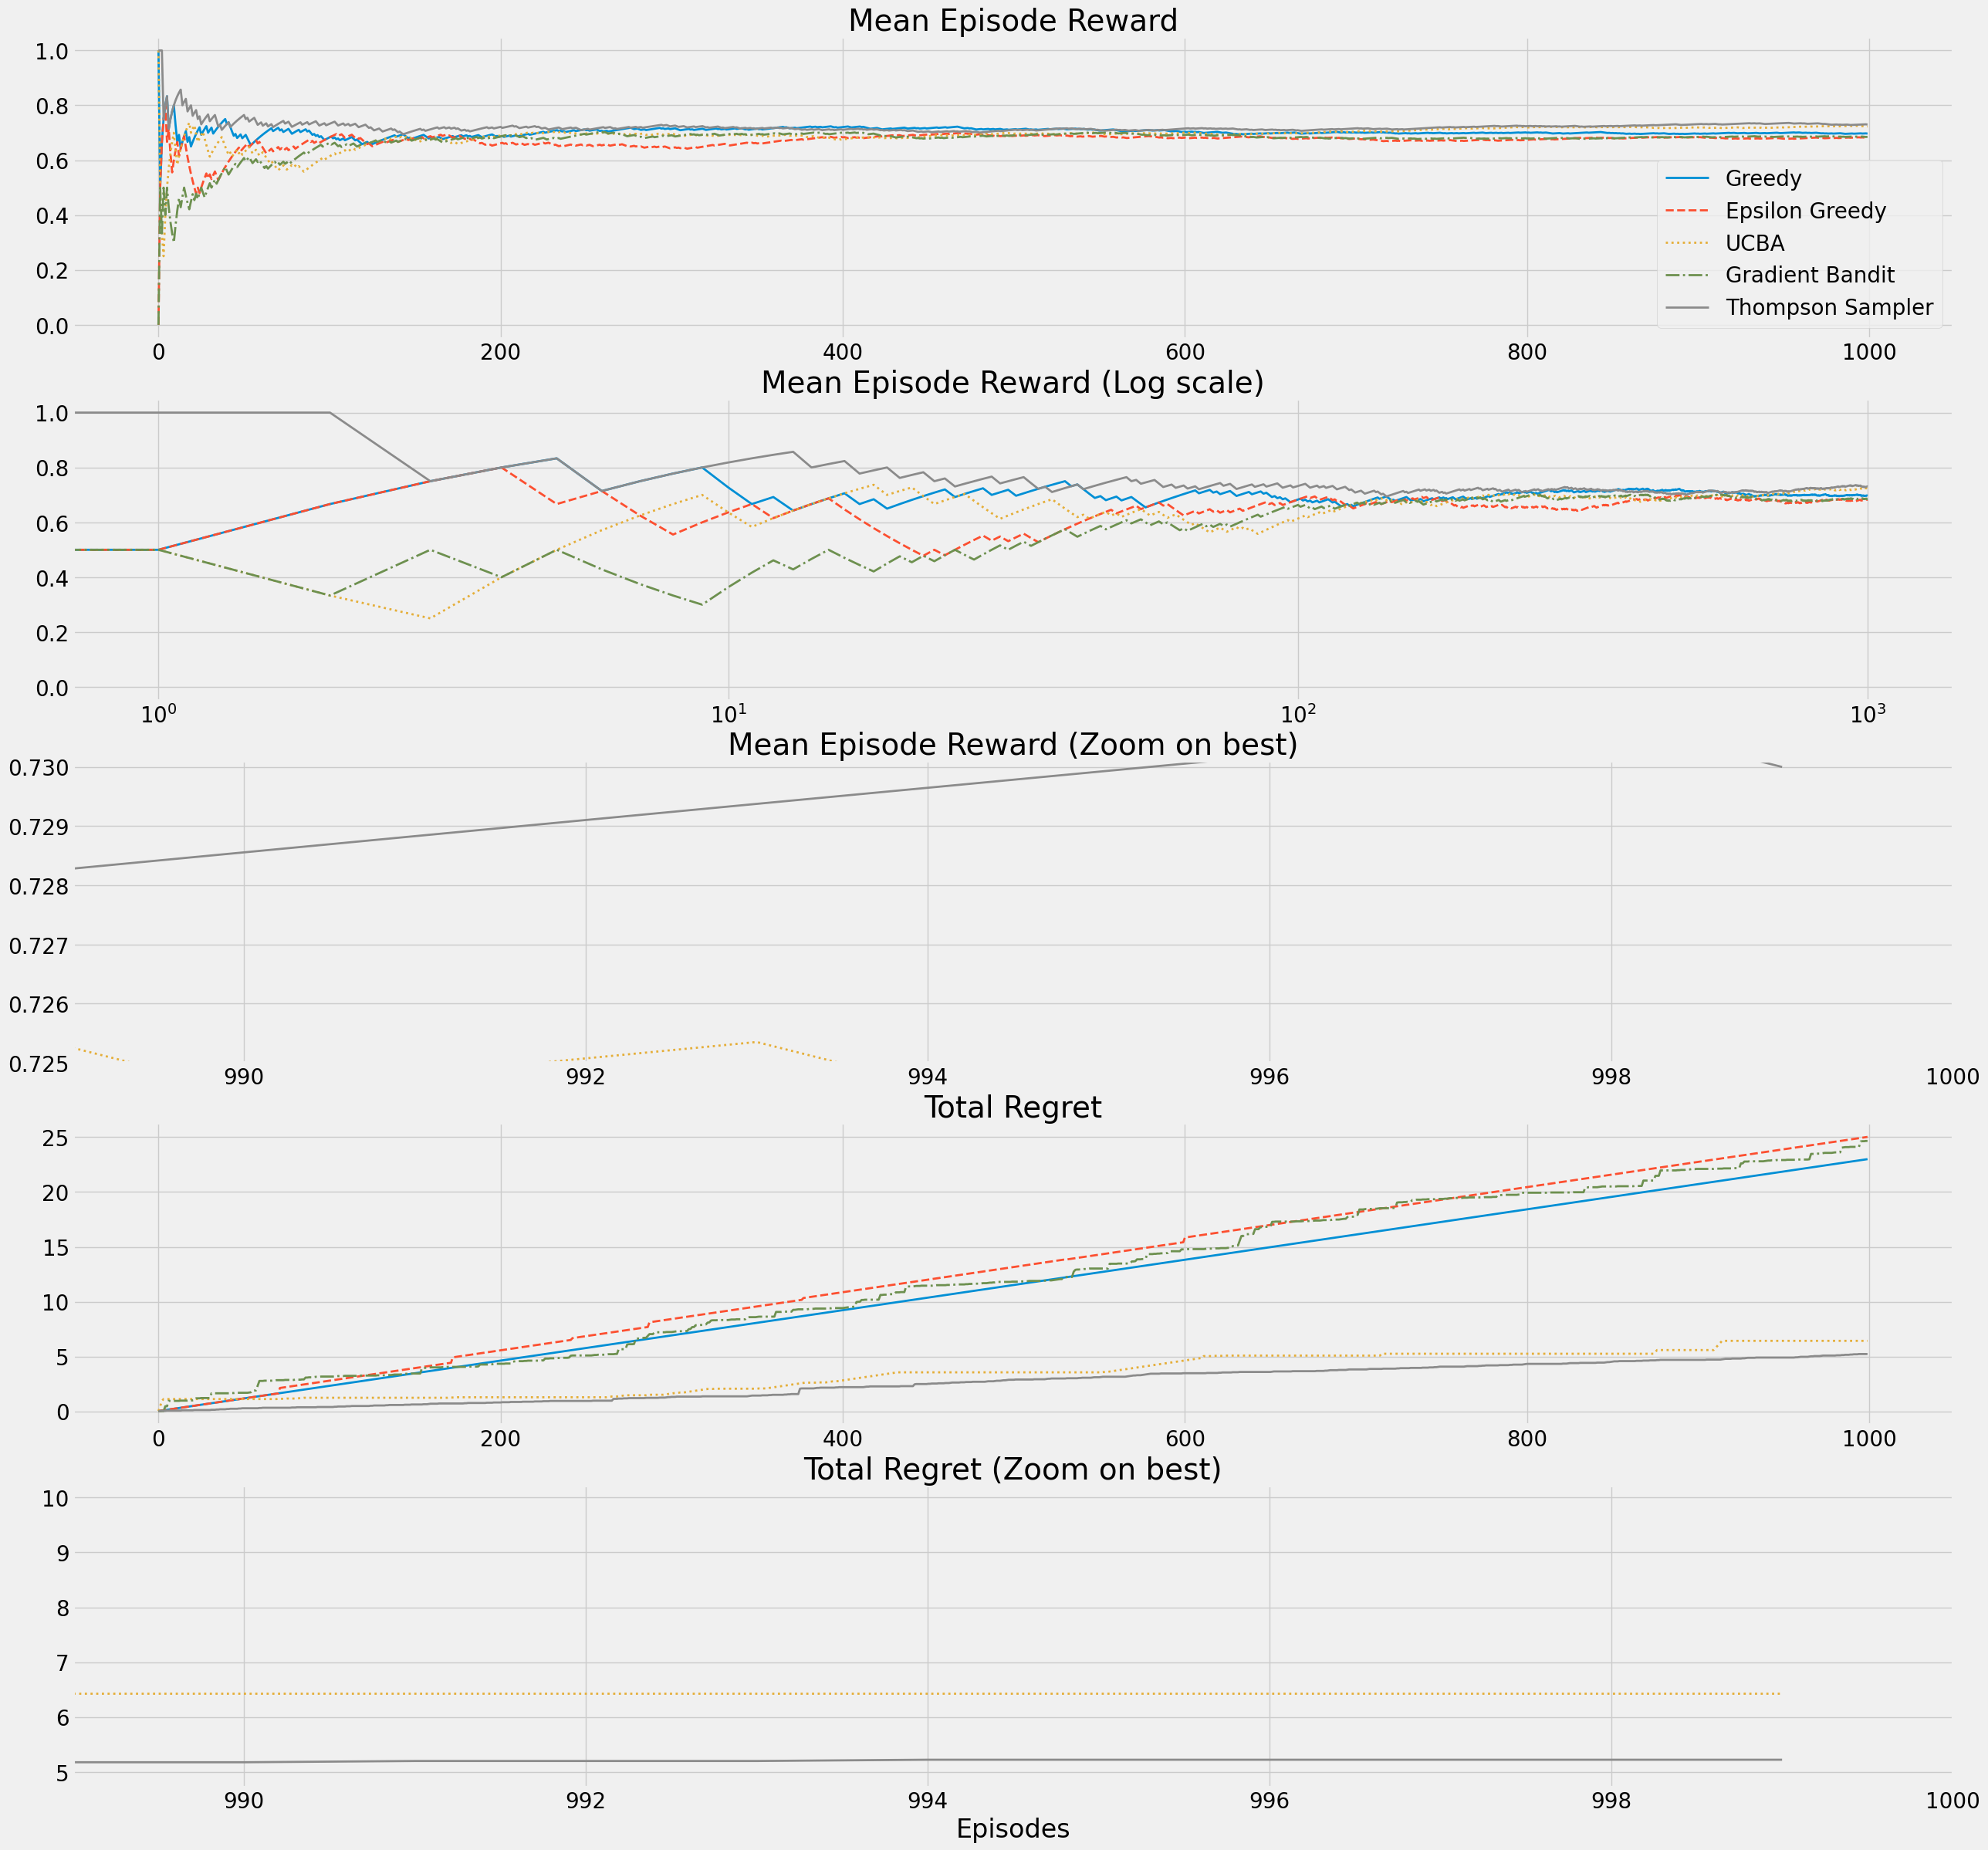

In [73]:
results={}
print(f'Probability of Rewards: {banditBern.probs}')
print(f'Optimal Rewards: {banditBern.optimal}')
print('_'*50)
for i in range(len(agentsBern)):
    agent=agentsBern[i]
    n_episodes = 1000
    Qe=np.empty((n_episodes, banditBern.getN()), dtype=np.float64)
    returns = np.empty(n_episodes, dtype=np.float64)
    actions = np.empty(n_episodes, dtype=int)

    for e in range(n_episodes):
        action=agent.action() if i != 2 else agent.action(e)
        reward=banditBern.choose(action)
        agent.update(action, reward)
        Q, N = agent.getQN()
        Qe[e]=Q
        returns[e] = reward
        actions[e]=action
    name=nameOfAgent[i]

    true_Q=banditBern.probs
    opt_V=banditBern.optimal
    name,Re,Qe,Ae=name,returns,Qe,actions
    Ae=np.expand_dims(Ae,-1)
    episode_mean_rew = np.cumsum(Re) / (np.arange(len(Re)) + 1)
    Q_selected = np.take_along_axis(
                        np.tile(true_Q, Ae.shape), Ae, axis=1).squeeze()
    regret = opt_V - Q_selected
    cum_regret = np.cumsum(regret)
    if name not in results.keys(): results[name] = {}
    if 'Re' not in results[name].keys(): results[name]['Re'] = []
    if 'Qe' not in results[name].keys(): results[name]['Qe'] = []
    if 'Ae' not in results[name].keys(): results[name]['Ae'] = []
    if 'cum_regret' not in results[name].keys(): 
                        results[name]['cum_regret'] = []
    if 'episode_mean_rew' not in results[name].keys(): 
                    results[name]['episode_mean_rew'] = []

    results[name]['Re'].append(Re)
    results[name]['Qe'].append(Qe)
    results[name]['Ae'].append(Ae)
    results[name]['cum_regret'].append(cum_regret)
    results[name]['episode_mean_rew'].append(episode_mean_rew)


fig, axs = plt.subplots(5, 1, figsize=(28, 28), sharey=False, sharex=False)

lines = ["-","--",":","-."]
linecycler = cycle(lines)
min_reg, max_ret = float('inf'), float('-inf')
for label, result in results.items():
    color = next(linecycler)

    # reward
    episode_mean_rew = np.array(result['episode_mean_rew'])
    mean_episode_mean_rew = np.mean(episode_mean_rew, axis=0)

    axs[0].plot(mean_episode_mean_rew, color, linewidth=2, label=label)

    axs[1].plot(mean_episode_mean_rew, color, linewidth=2, label=label)
    axs[1].set_xscale('log')
    
    axs[2].plot(mean_episode_mean_rew, color, linewidth=2, label=label)
    if max_ret < mean_episode_mean_rew[-1]: max_ret = mean_episode_mean_rew[-1]
    axs[2].axis((mean_episode_mean_rew.shape[0]*0.989,
                mean_episode_mean_rew.shape[0],
                max_ret-0.005,
                max_ret+0.0001))

    # regret
    cum_regret = np.array(result['cum_regret'])
    mean_cum_regret = np.mean(cum_regret, axis=0)

    axs[3].plot(mean_cum_regret, color, linewidth=2, label=label)
    
    axs[4].plot(mean_cum_regret, color, linewidth=2, label=label)
    if min_reg > mean_cum_regret[-1]: min_reg = mean_cum_regret[-1]
    plt.axis((mean_cum_regret.shape[0]*0.989,
            mean_cum_regret.shape[0],
            min_reg-0.5,
            min_reg+5))

    # config plot
    axs[0].set_title('Mean Episode Reward')
    axs[1].set_title('Mean Episode Reward (Log scale)')
    axs[2].set_title('Mean Episode Reward (Zoom on best)')
    axs[3].set_title('Total Regret')
    axs[4].set_title('Total Regret (Zoom on best)')
    plt.xlabel('Episodes')
    axs[0].legend()
plt.show()

Probability of Rewards in: [0.69646919 0.28613933 0.22685145 0.55131477 0.71946897]
Optimal Rewards: 0.7194689697855631
__________________________________________________


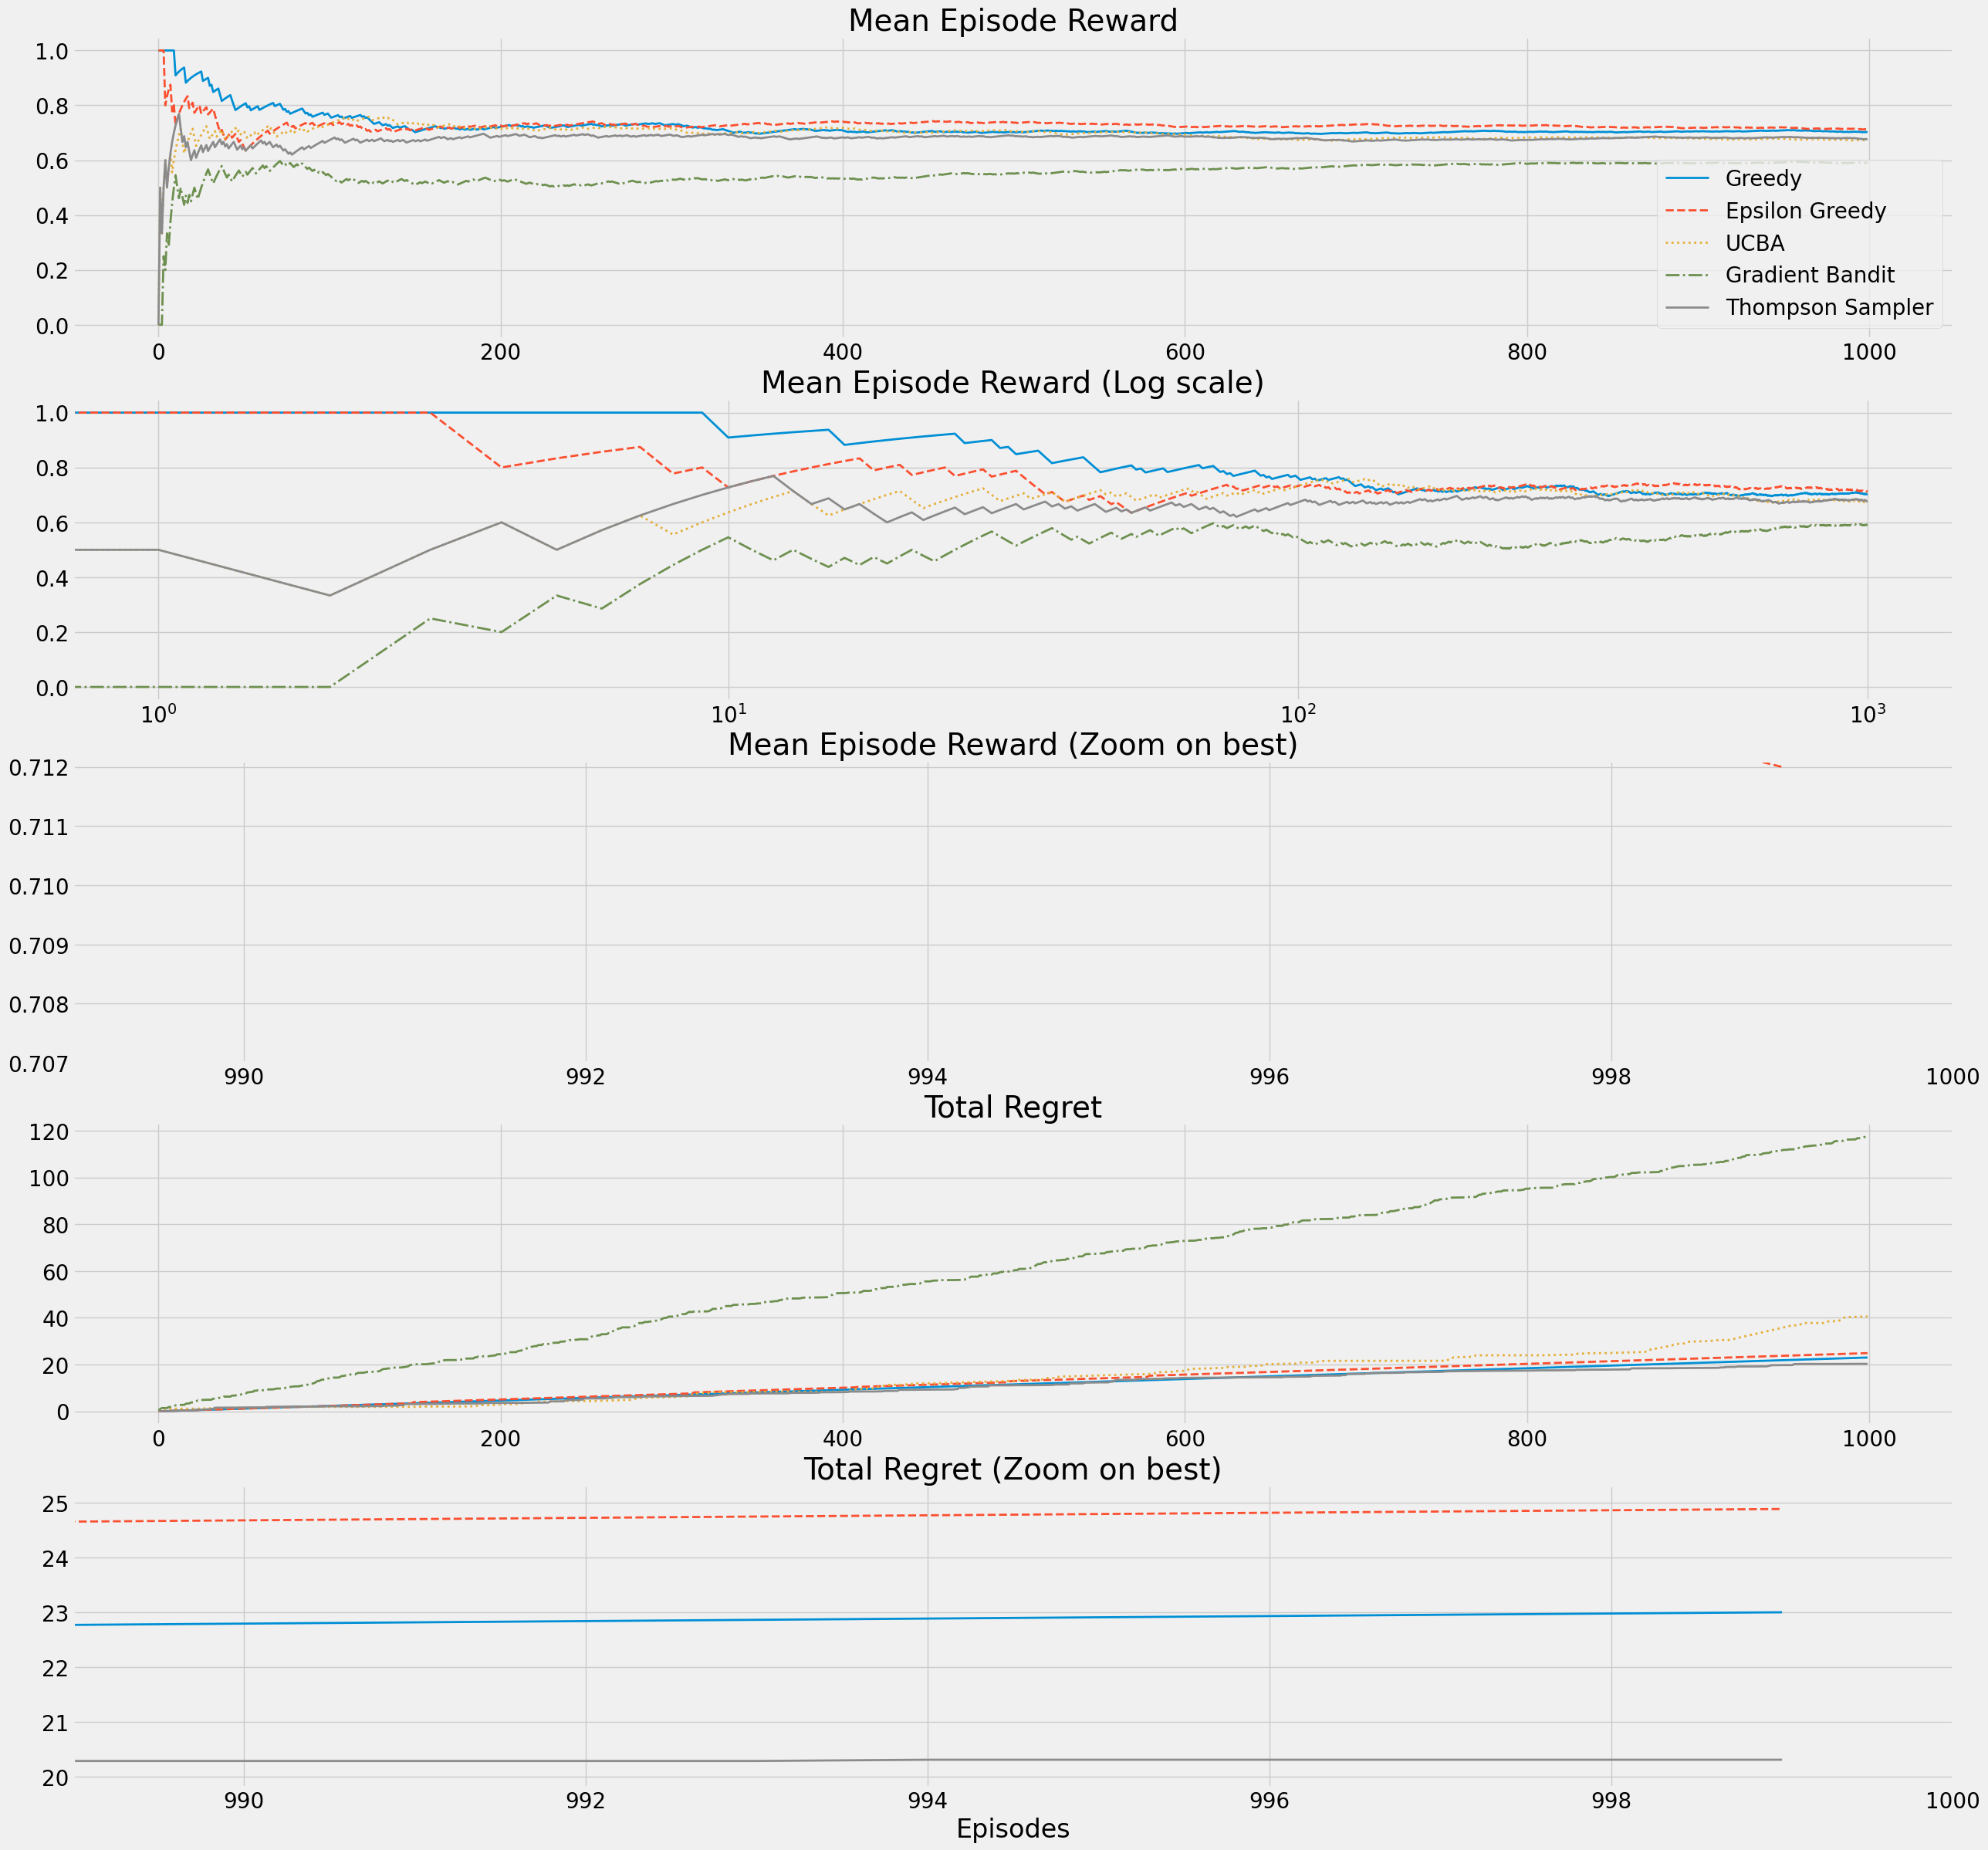

In [74]:
results={}
print(f'Probability of Rewards: {banditBern.probs}')
print(f'Optimal Rewards: {banditBern.optimal}')
print('_'*50)
for i in range(len(agentsGauss)):
    agent=agentsGauss[i]
    n_episodes = 1000
    Qe=np.empty((n_episodes, banditBern.getN()), dtype=np.float64)
    returns = np.empty(n_episodes, dtype=np.float64)
    actions = np.empty(n_episodes, dtype=int)

    for e in range(n_episodes):
        action=agent.action() if i != 2 else agent.action(e)
        reward=banditBern.choose(action)
        agent.update(action, reward)
        Q, N = agent.getQN()
        Qe[e]=Q
        returns[e] = reward
        actions[e]=action
    name=nameOfAgent[i]

    true_Q=banditBern.probs
    opt_V=banditBern.optimal
    name,Re,Qe,Ae=name,returns,Qe,actions
    Ae=np.expand_dims(Ae,-1)
    episode_mean_rew = np.cumsum(Re) / (np.arange(len(Re)) + 1)
    Q_selected = np.take_along_axis(
                        np.tile(true_Q, Ae.shape), Ae, axis=1).squeeze()
    regret = opt_V - Q_selected
    cum_regret = np.cumsum(regret)
    if name not in results.keys(): results[name] = {}
    if 'Re' not in results[name].keys(): results[name]['Re'] = []
    if 'Qe' not in results[name].keys(): results[name]['Qe'] = []
    if 'Ae' not in results[name].keys(): results[name]['Ae'] = []
    if 'cum_regret' not in results[name].keys(): 
                        results[name]['cum_regret'] = []
    if 'episode_mean_rew' not in results[name].keys(): 
                    results[name]['episode_mean_rew'] = []

    results[name]['Re'].append(Re)
    results[name]['Qe'].append(Qe)
    results[name]['Ae'].append(Ae)
    results[name]['cum_regret'].append(cum_regret)
    results[name]['episode_mean_rew'].append(episode_mean_rew)


fig, axs = plt.subplots(5, 1, figsize=(28, 28), sharey=False, sharex=False)

lines = ["-","--",":","-."]
linecycler = cycle(lines)
min_reg, max_ret = float('inf'), float('-inf')
for label, result in results.items():
    color = next(linecycler)

    # reward
    episode_mean_rew = np.array(result['episode_mean_rew'])
    mean_episode_mean_rew = np.mean(episode_mean_rew, axis=0)

    axs[0].plot(mean_episode_mean_rew, color, linewidth=2, label=label)

    axs[1].plot(mean_episode_mean_rew, color, linewidth=2, label=label)
    axs[1].set_xscale('log')
    
    axs[2].plot(mean_episode_mean_rew, color, linewidth=2, label=label)
    if max_ret < mean_episode_mean_rew[-1]: max_ret = mean_episode_mean_rew[-1]
    axs[2].axis((mean_episode_mean_rew.shape[0]*0.989,
                mean_episode_mean_rew.shape[0],
                max_ret-0.005,
                max_ret+0.0001))

    # regret
    cum_regret = np.array(result['cum_regret'])
    mean_cum_regret = np.mean(cum_regret, axis=0)

    axs[3].plot(mean_cum_regret, color, linewidth=2, label=label)
    
    axs[4].plot(mean_cum_regret, color, linewidth=2, label=label)
    if min_reg > mean_cum_regret[-1]: min_reg = mean_cum_regret[-1]
    plt.axis((mean_cum_regret.shape[0]*0.989,
            mean_cum_regret.shape[0],
            min_reg-0.5,
            min_reg+5))

    # config plot
    axs[0].set_title('Mean Episode Reward')
    axs[1].set_title('Mean Episode Reward (Log scale)')
    axs[2].set_title('Mean Episode Reward (Zoom on best)')
    axs[3].set_title('Total Regret')
    axs[4].set_title('Total Regret (Zoom on best)')
    plt.xlabel('Episodes')
    axs[0].legend()
    

plt.show()